# Maternal Health Risk Project Notebook

This notebook implements the following: data description, exploration and visualization, machine learning with one classical model and one neural network, evaluation metrics and findings.

## Data Description

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
CSV_PATH = 'Dataset - Updated.csv'
TARGET = 'Risk Level'
FEATURES = [
    'Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp',
    'BMI', 'Previous Complications', 'Preexisting Diabetes',
    'Gestational Diabetes', 'Mental Health', 'Heart Rate'
]

df_raw = pd.read_csv(CSV_PATH)
print('Shape:', df_raw.shape)
print('\nTarget classes:')
print(df_raw[TARGET].value_counts())
print('\nData types:')
print(df_raw.dtypes)
print('\nFirst 5 rows:')
display(df_raw.head())
print('\nSummary statistics:')
display(df_raw.describe())
print('\nMissing values:')
display(df_raw.isnull().sum().to_frame('missing_count'))

Shape: (1205, 12)

Target classes:
Risk Level
Low     713
High    474
Name: count, dtype: int64

Data types:
Age                         int64
Systolic BP               float64
Diastolic                 float64
BS                        float64
Body Temp                   int64
BMI                       float64
Previous Complications    float64
Preexisting Diabetes      float64
Gestational Diabetes        int64
Mental Health               int64
Heart Rate                float64
Risk Level                    str
dtype: object

First 5 rows:


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low



Summary statistics:


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.731950,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,12.571074,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,32.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,325.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000



Missing values:


,missing_count
Age,0
Systolic BP,5
Diastolic,4
BS,2
Body Temp,0
BMI,18
Previous Complications,2
Preexisting Diabetes,2
Gestational Diabetes,0
Mental Health,0


## Data Exploration and Visualization

Coverage:
- Univariate and multivariate visualizations
- Axes labels and titles included
- Interpretation written below each figure

In [3]:
df = df_raw.copy()
df = df.dropna(subset=[TARGET])
df = df[df['Age'] <= 60]

imputer = SimpleImputer(strategy='median')
df[FEATURES] = imputer.fit_transform(df[FEATURES])

le = LabelEncoder()
df['label'] = le.fit_transform(df[TARGET])
class_map = dict(zip(le.classes_, le.transform(le.classes_)))
if class_map.get('High', 1) == 0:
    df['label'] = 1 - df['label']

print('Cleaned shape:', df.shape)
print(df[TARGET].value_counts())

Cleaned shape: (1184, 13)
Risk Level
Low     712
High    472
Name: count, dtype: int64


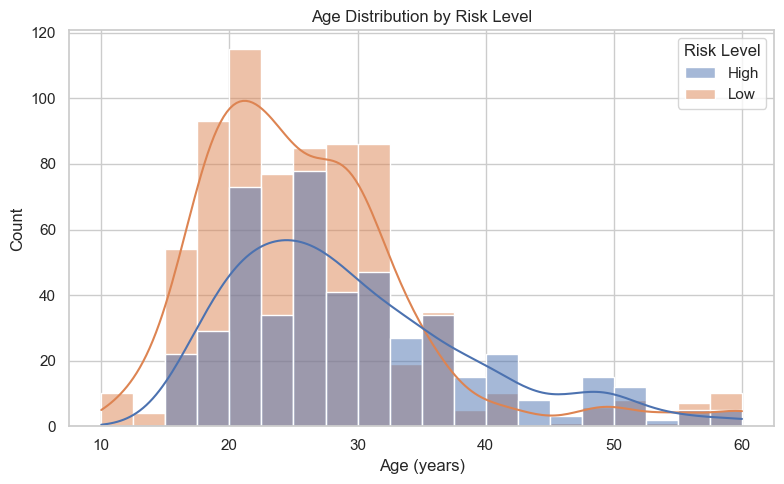

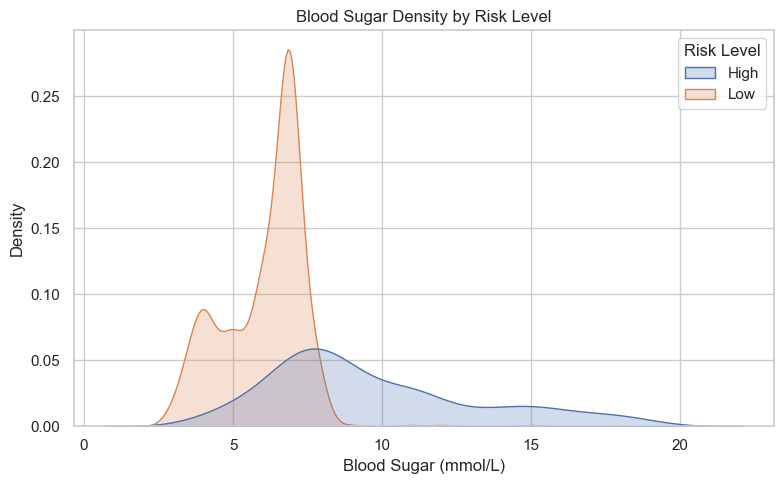

In [4]:
# Univariate 1: Age distribution by risk level
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue=TARGET, kde=True, bins=20)
plt.title('Age Distribution by Risk Level')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Univariate 2: Blood sugar distribution by risk level
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='BS', hue=TARGET, fill=True)
plt.title('Blood Sugar Density by Risk Level')
plt.xlabel('Blood Sugar (mmol/L)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### Interpretation (Univariate)
- Age distribution suggests older mothers are more represented in the high-risk group.
- Blood sugar values tend to shift higher for high-risk cases, indicating glycemic control is an important risk indicator.

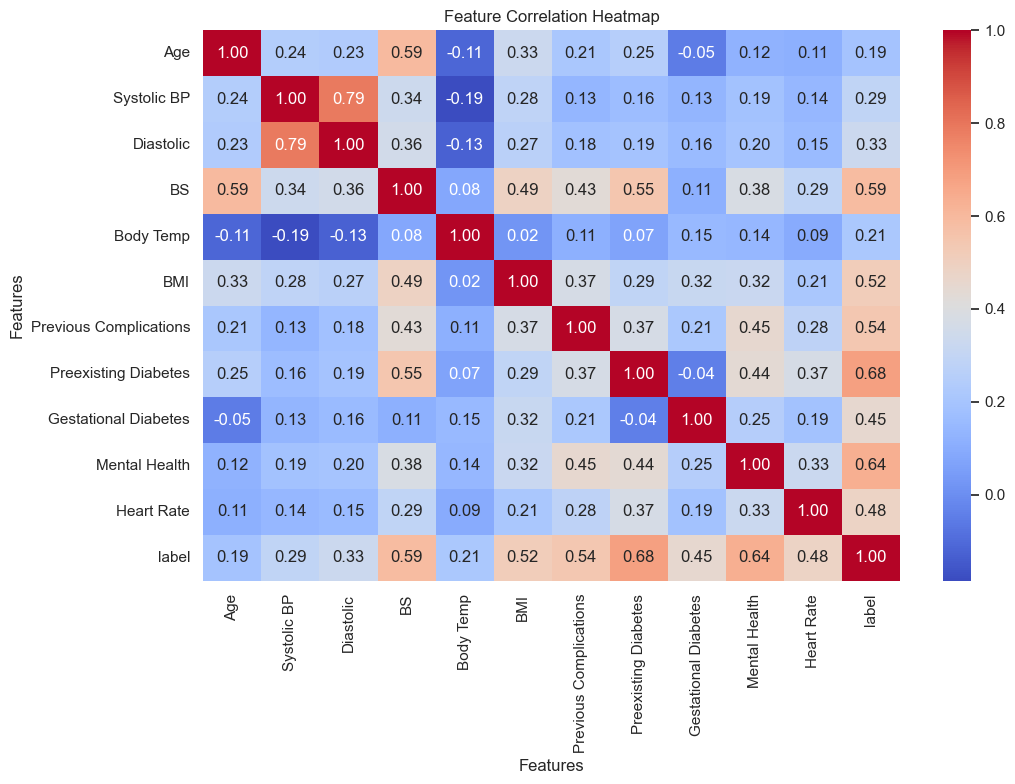

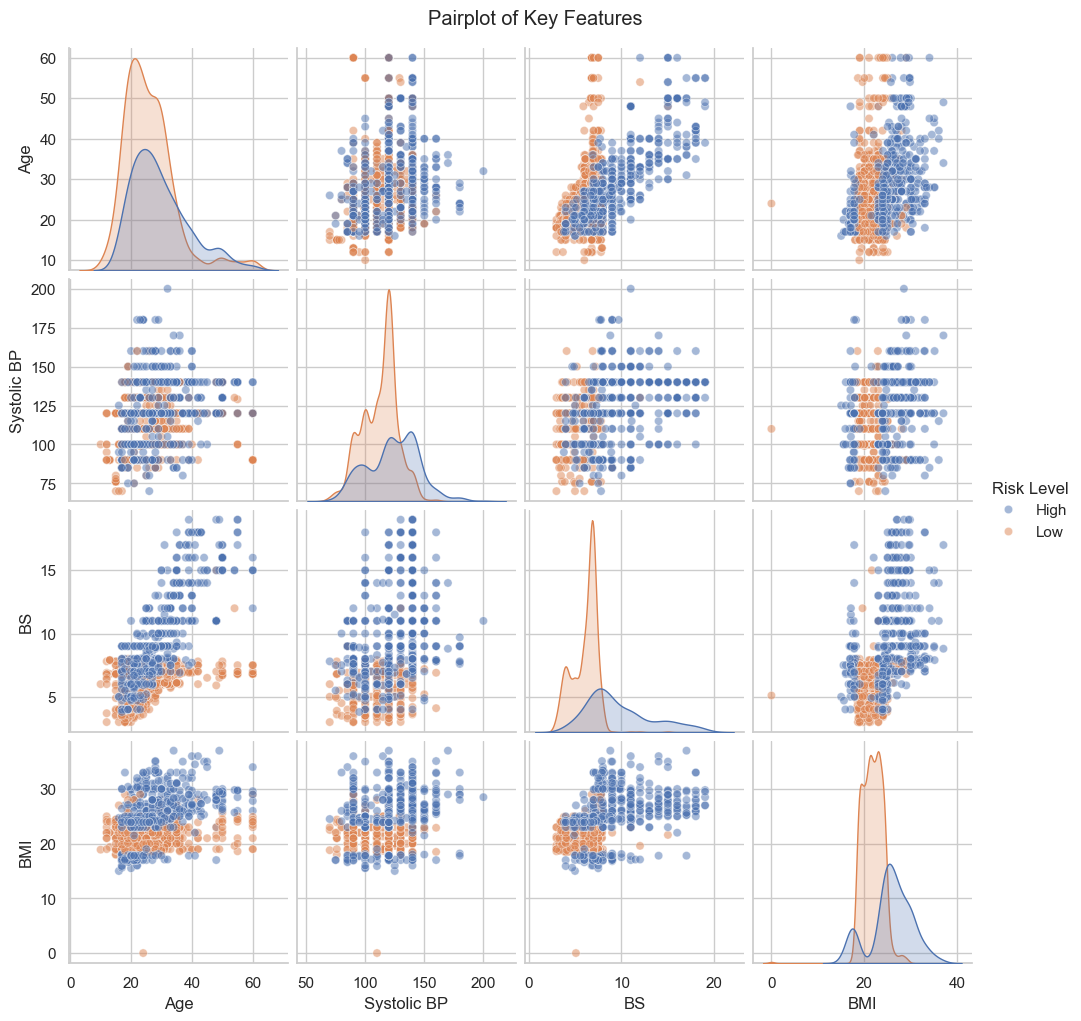

In [5]:
# Multivariate 1: Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df[FEATURES + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Multivariate 2: Pairplot for selected features
pair_cols = ['Age', 'Systolic BP', 'BS', 'BMI', TARGET]
pairplot_obj = sns.pairplot(df[pair_cols], hue=TARGET, diag_kind='kde', plot_kws={'alpha': 0.5})
pairplot_obj.figure.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

### Interpretation (Multivariate)
- Systolic BP and Diastolic are positively correlated, consistent with related cardiovascular behavior.
- Pairplot clusters show better separation between risk classes when blood sugar and blood pressure are considered together.

## Machine Learning

This section includes:
- Data cleaning and preparation
- One classical model (Random Forest)
- One neural network (Keras MLP)
- Evaluation metrics

In [11]:
X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 947
Test size: 237


In [7]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
    }
    return metrics

rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

rf_metrics = evaluate_model(y_test, y_pred_rf, y_prob_rf, 'Random Forest')
print('Random Forest metrics:')
display(pd.DataFrame([rf_metrics]))
print('\nClassification report (RF):')
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'High']))

Random Forest metrics:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.991561,0.989362,0.989362,0.989362,0.999182



Classification report (RF):
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       143
        High       0.99      0.99      0.99        94

    accuracy                           0.99       237
   macro avg       0.99      0.99      0.99       237
weighted avg       0.99      0.99      0.99       237



In [8]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

nn_model = build_mlp(X_train_sc.shape[1])
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    mode='max',
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

y_prob_nn = nn_model.predict(X_test_sc, verbose=0).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

nn_metrics = evaluate_model(y_test, y_pred_nn, y_prob_nn, 'Neural Network')
print('Neural Network metrics:')
display(pd.DataFrame([nn_metrics]))
print('\nClassification report (NN):')
print(classification_report(y_test, y_pred_nn, target_names=['Low', 'High']))

Neural Network metrics:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Neural Network,0.978903,0.978495,0.968085,0.973262,0.998958



Classification report (NN):
              precision    recall  f1-score   support

         Low       0.98      0.99      0.98       143
        High       0.98      0.97      0.97        94

    accuracy                           0.98       237
   macro avg       0.98      0.98      0.98       237
weighted avg       0.98      0.98      0.98       237



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.991561,0.989362,0.989362,0.989362,0.999182
1,Neural Network,0.978903,0.978495,0.968085,0.973262,0.998958


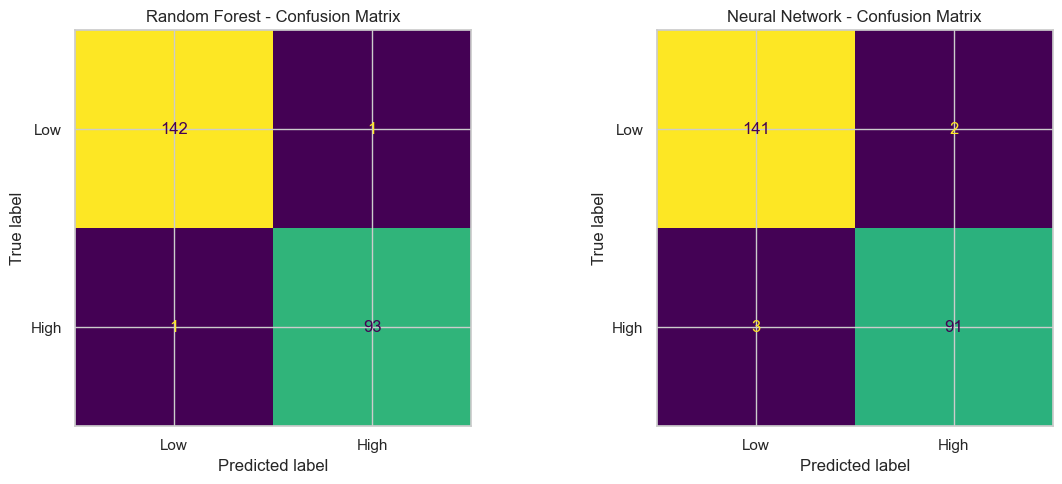

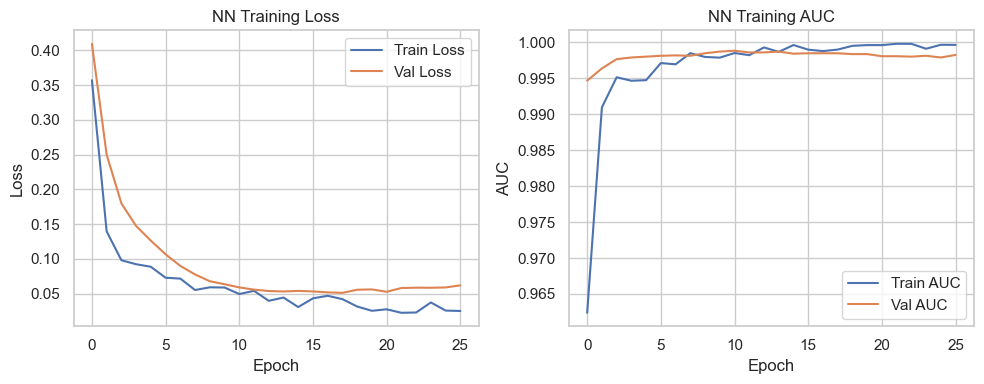

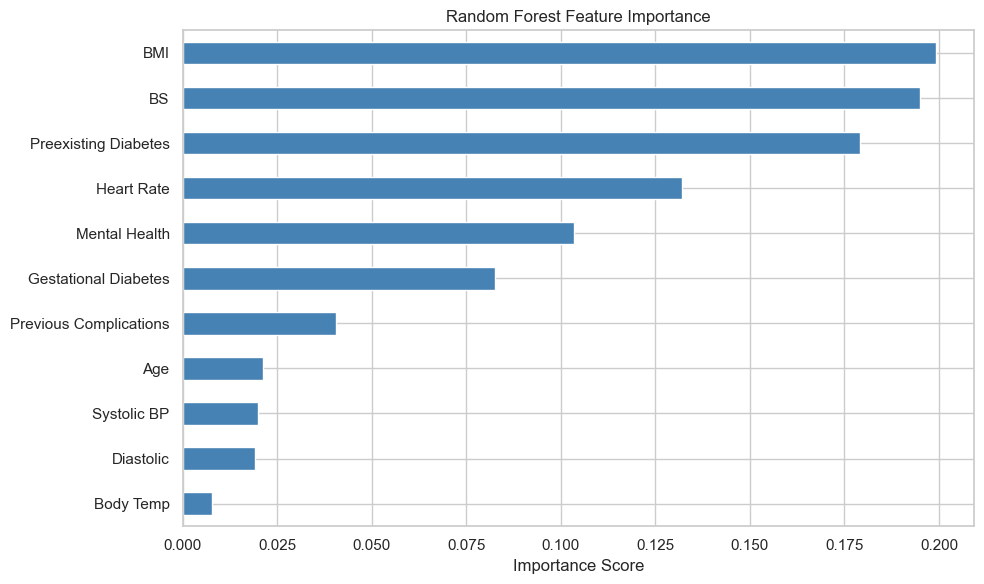

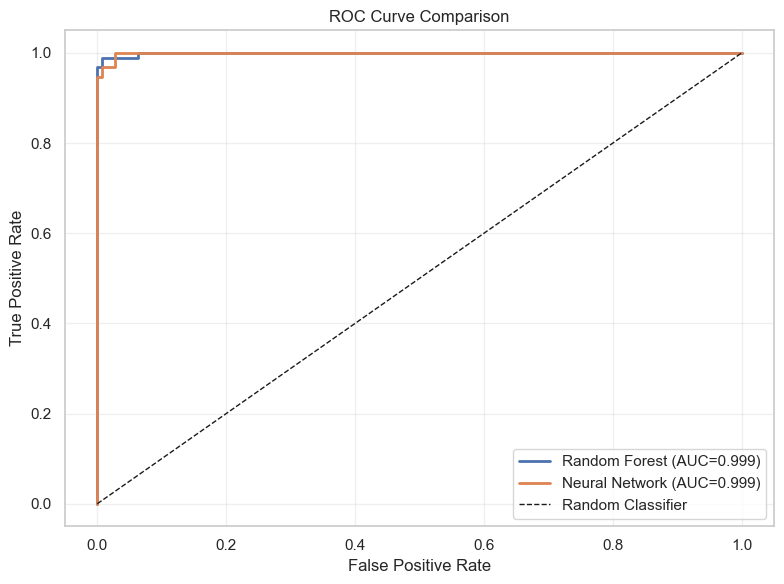

In [9]:
metrics_df = pd.DataFrame([rf_metrics, nn_metrics])
display(metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Low', 'High']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest - Confusion Matrix')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nn), display_labels=['Low', 'High']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Neural Network - Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('NN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('NN Training AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance from Random Forest
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ROC curve comparison
from sklearn.metrics import roc_curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC={roc_auc_score(y_test, y_prob_nn):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')
nn_model.save('neural_network_model.keras')

print('Saved random_forest_model.pkl, scaler.pkl, imputer.pkl, neural_network_model.keras')

Saved random_forest_model.pkl, scaler.pkl, imputer.pkl, neural_network_model.keras


## Notes

Key findings:
1. High-risk outcomes are associated with higher blood sugar and blood pressure patterns.
2. Both models perform well, with evaluation based on accuracy, precision, recall, F1, and ROC-AUC.
3. The Random Forest offers strong interpretability through feature importance, while the neural network captures non-linear relationships.
4. The separate dashboard app in dashboard.py provides an interactive demo interface for predictions.